# Feature and alignment inspection

Visual checks of the classical stage on **calibration WIDs only** (never on development or benchmark queries). Every computation is a call into `cover_retrieval`; the notebook contains no pipeline logic of its own.

1. raw vs. preprocessed HPCP for two cover pairs and two non-cover pairs
2. the 12 key-rotation scores
3. cross-similarity (cosine-distance) matrices with subsequence-DTW paths

In [1]:
import os
from pathlib import Path

# run from the repository root regardless of where Jupyter was started
if Path.cwd().name == 'notebooks':
    os.chdir('..')

CONFIG = 'configs/base.yaml'   # or 'configs/smoke.yaml' for the synthetic fixture

import matplotlib.pyplot as plt
import numpy as np

from cover_retrieval.data.datacos import feature_path, features_root, load_hpcp
from cover_retrieval.data.manifests import load_protocol
from cover_retrieval.evaluation.analysis import plot_alignment
from cover_retrieval.features.hpcp import to_pitch_by_time
from cover_retrieval.pipeline import pair_diagnostics, protocol_store
from cover_retrieval.utils.io import load_config

config = load_config(CONFIG)
protocol = load_protocol(config['paths']['manifests_dir'], 'calibration')
store = protocol_store(config, protocol, 'coveranalysis')
by_wid = {}
for t in protocol.queries:
    by_wid.setdefault(t.wid, []).append(t)
wids = sorted(by_wid)
covers = [tuple(by_wid[w]) for w in wids[:2]]
noncovers = [(by_wid[wids[0]][0], by_wid[wids[2]][0]), (by_wid[wids[1]][0], by_wid[wids[3]][0])]
pairs = [('cover', a, b) for a, b in covers] + [('non-cover', a, b) for a, b in noncovers]
print(len(protocol.queries), 'calibration tracks;', [(k, a.pid, b.pid) for k, a, b in pairs])

20 calibration tracks; [('cover', 'P_510723', 'P_77960'), ('cover', 'P_242247', 'P_476324'), ('non-cover', 'P_510723', 'P_355091'), ('non-cover', 'P_242247', 'P_130947')]


## 1. Raw vs. preprocessed HPCP

Raw Da-TACOS HPCP is `(T, 12)`, max-normalised per frame; the classical view is `(12, 96)`: frame-L2 → area resampling → frame-L2.

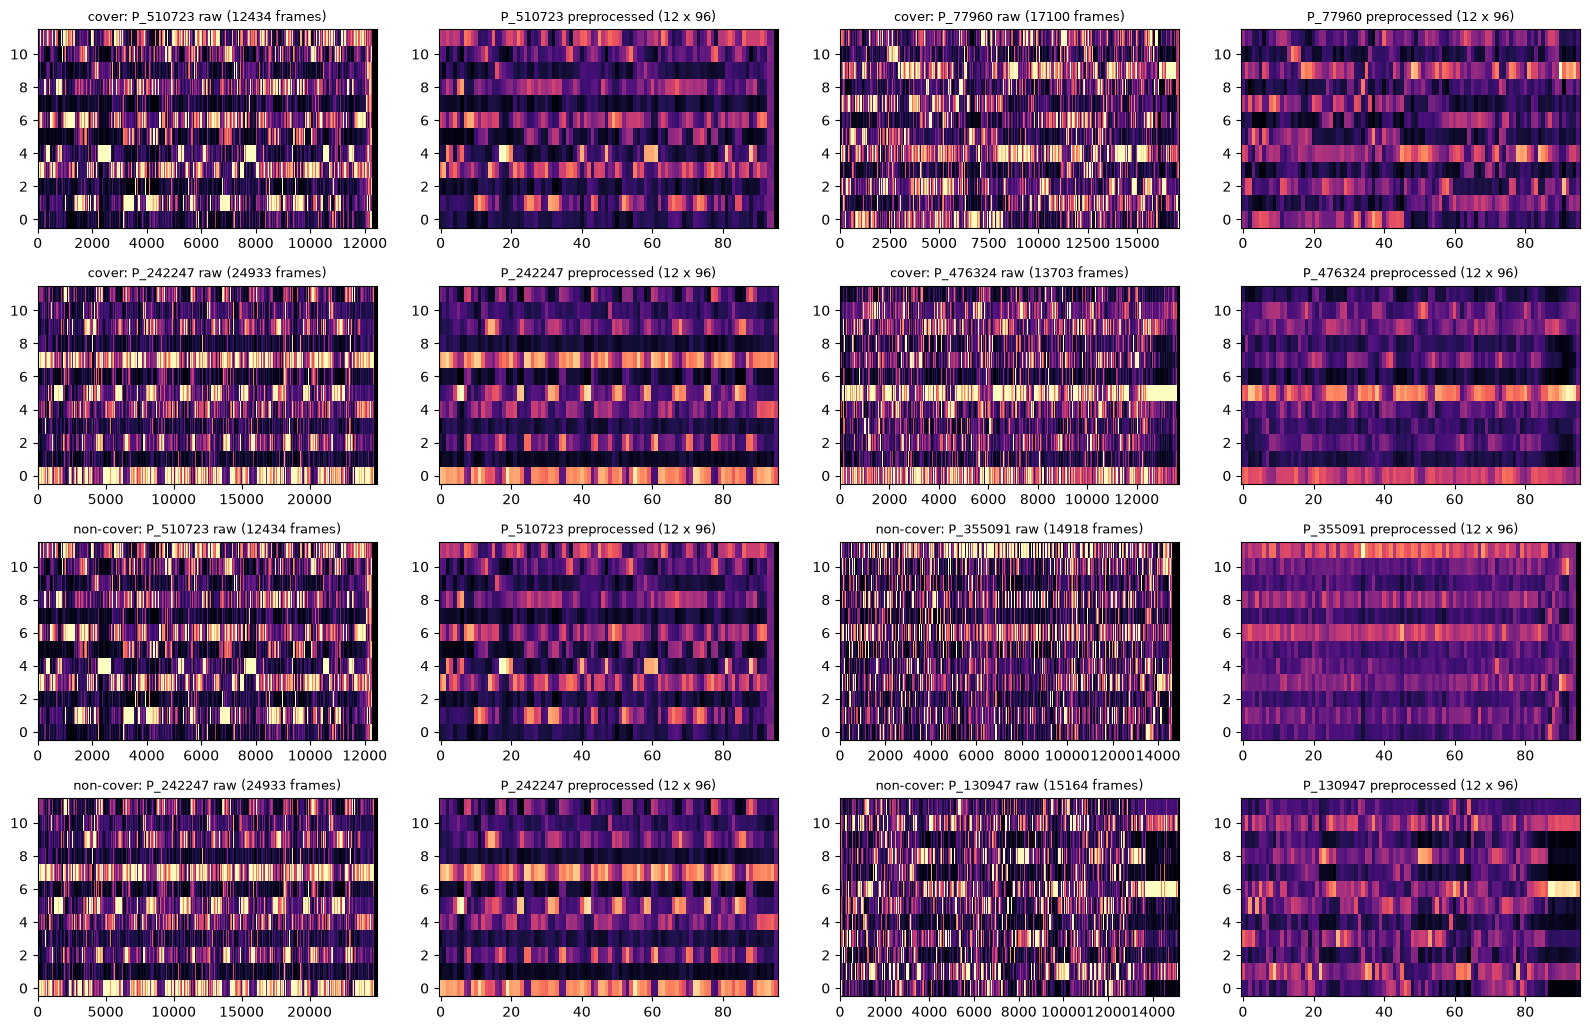

In [2]:
root = features_root(config, 'coveranalysis')
fig, axes = plt.subplots(len(pairs), 4, figsize=(16, 2.6 * len(pairs)))
for row, (kind, a, b) in enumerate(pairs):
    for col, t in enumerate((a, b)):
        raw = to_pitch_by_time(load_hpcp(feature_path(root, t.wid, t.pid)).hpcp)
        axes[row, 2 * col].imshow(raw, aspect='auto', origin='lower', cmap='magma', interpolation='nearest')
        axes[row, 2 * col].set_title(f'{kind}: {t.pid} raw ({raw.shape[1]} frames)', fontsize=9)
        axes[row, 2 * col + 1].imshow(store.get('classical', [t.pid])[0], aspect='auto', origin='lower', cmap='magma')
        axes[row, 2 * col + 1].set_title(f'{t.pid} preprocessed (12 x 96)', fontsize=9)
plt.tight_layout()

## 2. Key rotation scores

Cosine between time-averaged chroma profiles for each of the 12 candidate rotations; the arg-max is the rotation used for alignment.

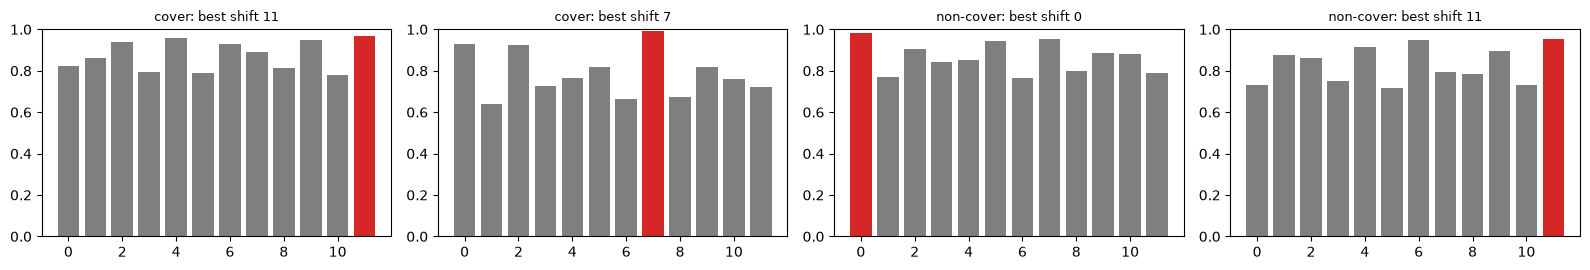

In [3]:
diags = [pair_diagnostics(config, *store.get('classical', [a.pid, b.pid])) for _, a, b in pairs]
fig, axes = plt.subplots(1, len(pairs), figsize=(16, 2.8))
for ax, (kind, a, b), d in zip(axes, pairs, diags):
    ax.bar(range(12), d.rotation_scores, color=['tab:red' if k == d.shift else 'tab:gray' for k in range(12)])
    ax.set_title(f'{kind}: best shift {d.shift}', fontsize=9)
    ax.set_ylim(0, 1)
plt.tight_layout()

## 3. Cross-similarity matrices and subsequence-DTW paths

Cosine distance between query frames (rows) and rotated candidate frames (columns); red = optimal slope-constrained subsequence path. Lower normalised cost = better match.

cover       P_510723 vs    P_77960  shift=11  normalised cost=0.1238
cover       P_242247 vs   P_476324  shift= 7  normalised cost=0.0422
non-cover   P_510723 vs   P_355091  shift= 0  normalised cost=0.1095
non-cover   P_242247 vs   P_130947  shift=11  normalised cost=0.1089


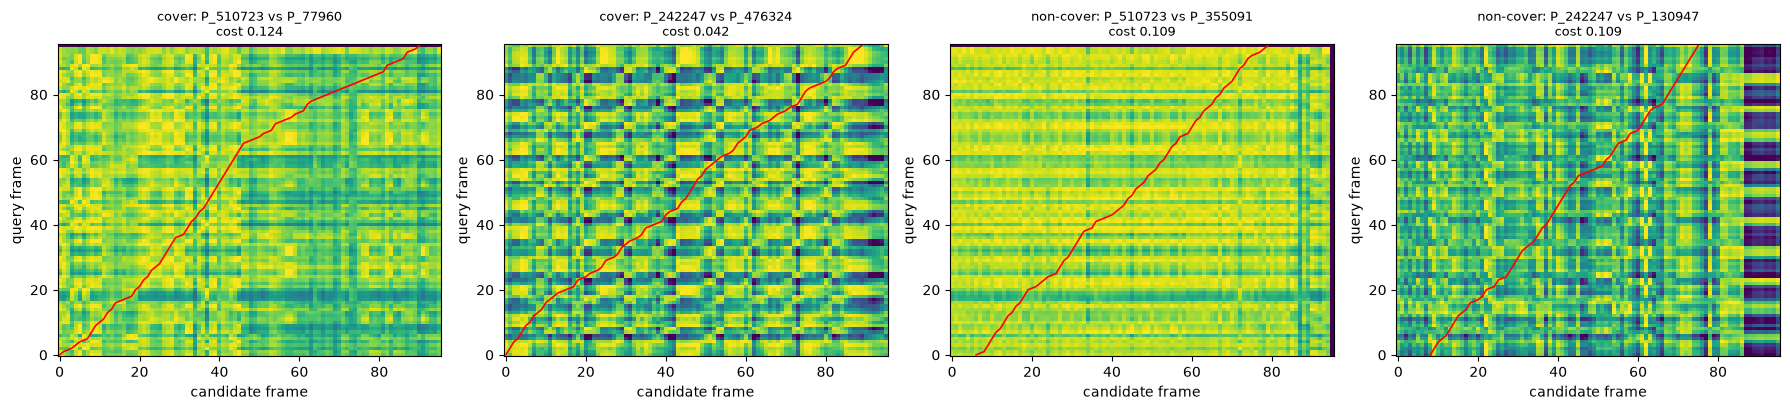

In [4]:
fig, axes = plt.subplots(1, len(pairs), figsize=(18, 4.2))
for ax, (kind, a, b), d in zip(axes, pairs, diags):
    plot_alignment(d.cost, d.dtw.path, f'{kind}: {a.pid} vs {b.pid}\ncost {d.dtw.normalized_cost:.3f}', None, ax=ax)
plt.tight_layout()
for (kind, a, b), d in zip(pairs, diags):
    print(f'{kind:9s} {a.pid:>10s} vs {b.pid:>10s}  shift={d.shift:2d}  normalised cost={d.dtw.normalized_cost:.4f}')

### Reading the plots

* A true cover typically shows a darker diagonal band that the path follows; non-covers produce a flatter matrix.
* At 96 frames per track each column averages a large stretch of raw frames, so the band is coarse; see the resolution sensitivity analysis in `reports/classical_baseline.md`.
* A low cost for a non-cover (shared common progression) is exactly the false-positive mechanism discussed in `reports/error_analysis.md`.